# 全盲预处理与多曝光联合检测（不训练 ASTERIS）

**本次验收限制：**保留的十张背景同帧样本中，64 像素块背景起伏中位数由约 12 DN 上升至 29 DN。
较保守的 64 像素网格尚未证明更优；训练前应进行 32/64 网格的背景与注入源对照。
全部联合检测仍有共有结构警告，`90000005_2` 有 69/80 帧 PSF 回退、80/80 帧透过率回退。

1. 1/f 与背景处理不读取星表/测量表，掩膜只来自探测器质量和图像自动检测。
2. 配准使用图像自动星点；坏像元先排除，再按有效插值权重归一化。
3. 按 Zackay & Ofek I 构建逐曝光 PSF 匹配检测统计量，输出覆盖数、经验显著性、奇偶检验和盲检列表。

参考：[Paper I](https://arxiv.org/abs/1512.06872)、[Paper II](https://arxiv.org/abs/1512.06879)。
PDF 已保存到项目上一级的 `paper`。这里实现的是 Paper I 的高斯 PSF 近似基线，**不是** Paper II 的 proper coadd。
星表只能在检测输出冻结后供人工核验；处理单元不读取星表，末尾提供独立的只读标注展示。

In [1]:
from pathlib import Path
import sys, subprocess, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from IPython.display import display
start=Path.cwd().resolve()
ROOT=next(p for p in (start,*start.parents) if (p/'src/astr_ir').is_dir())
sys.path.insert(0,str(ROOT/'src'))
PROCESSED=ROOT/'data/processed'
OLD=PROCESSED/'comparison_before_blind_v2'
JOINT=PROCESSED/'blind_joint'
sequences=sorted(p.name for p in (PROCESSED/'background').iterdir() if p.is_dir())
print(sequences)

['90000002', '90000003', '90000004', '90000005_1', '90000005_2']


## 1. 运行入口（默认不执行，防止查看 Notebook 时覆盖产品）

完整命令会先在 `comparison_before_blind_v2/{flicker,background}/{sequence}` 各保存首末两张旧科学图，
以 `old_` 开头，再更新原来的 1/f 与背景输出路径。中断可加 `--resume`，不会覆盖旧对比备份。
此流程不修改 raw，不运行网络训练/推理，也不覆盖已有 ASTERIS coadd。

In [2]:
RUN_PREPROCESS=False
RESUME_PREPROCESS=True
RUN_JOINT=False
if RUN_PREPROCESS:
    command=[sys.executable,str(ROOT/'scripts/maintenance/run_pre_asteris.py'),'--workers','2']
    if RESUME_PREPROCESS: command.append('--resume')
    subprocess.run(command,cwd=ROOT,check=True)
if RUN_JOINT:
    subprocess.run([sys.executable,str(ROOT/'scripts/evaluation/run_blind_joint_detection.py')],cwd=ROOT,check=True)

## 2. 全帧状态与背景指标（不能替代真实源完备率）

In [3]:
for stage in ('flicker','background'):
    table=pd.read_csv(PROCESSED/stage/f'{stage}_statistics.csv',dtype={'sequence':str})
    display(table.groupby(['sequence','status']).size().rename('frames').to_frame())
    assert len(table)==400
    assert (table.equation_max_abs_error_float32==0).all()
    assert not table.photometry_gate_active.any()
    metric='relative_reduction' if stage=='flicker' else 'large_scale_reduction'
    display(table.groupby('sequence')[metric].agg(['median','min','max']))

,,frames
sequence,status,
90000002,corrected,80
90000003,corrected,80
90000004,corrected,80
90000005_1,corrected,80
90000005_2,corrected,80


,median,min,max
sequence,,,
90000002,0.579625,0.507243,1.0
90000003,0.578153,0.507700,1.0
90000004,0.573413,0.488078,1.0
90000005_1,0.564665,0.470091,1.0
90000005_2,0.652246,0.488899,1.0


,,frames
sequence,status,
90000002,background_subtracted,80
90000003,background_subtracted,80
90000004,background_subtracted,80
90000005_1,background_subtracted,80
90000005_2,background_subtracted,80


,median,min,max
sequence,,,
90000002,0.839565,0.818889,0.860684
90000003,0.834030,0.794704,0.857704
90000004,0.842012,0.825546,0.861084
90000005_1,0.844989,0.825032,0.860671
90000005_2,0.818345,0.796122,0.846502


## 3. 旧/新同一帧对比（相同色标，显示时去除全局中位数）

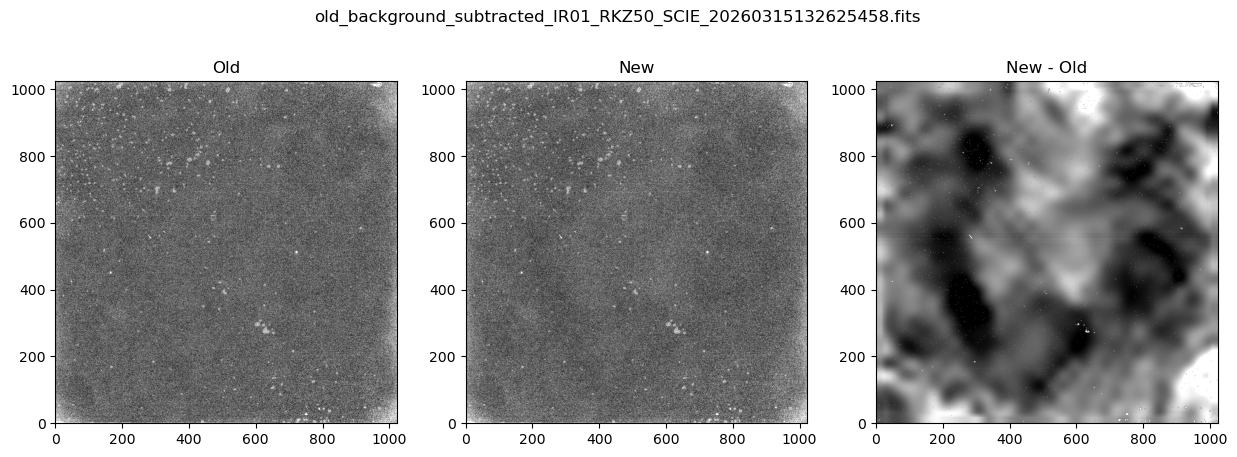

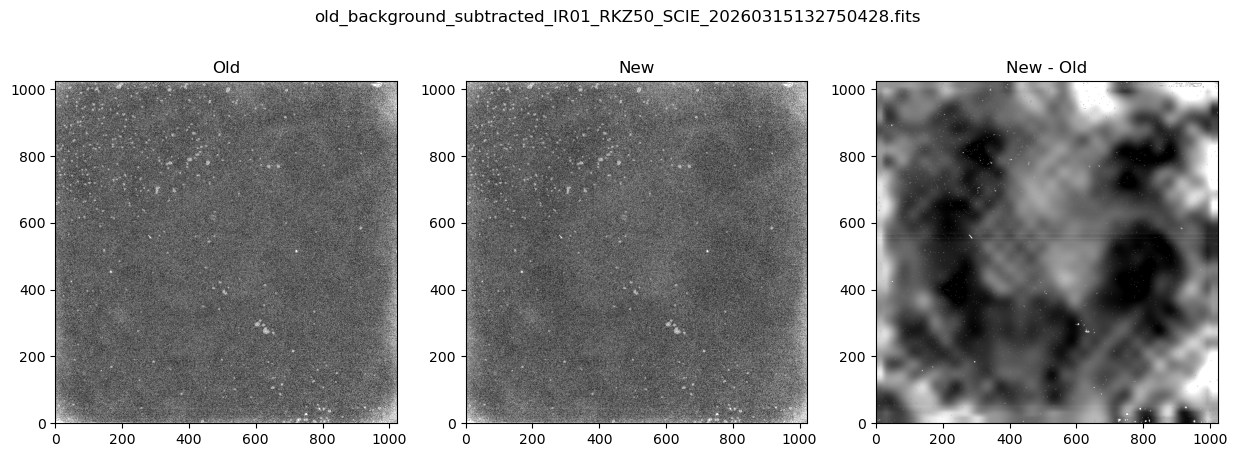

In [4]:
SEQUENCE=sequences[0]
STAGE='background'
old_paths=sorted((OLD/STAGE/SEQUENCE).glob('old_*.fits'))
for old_path in old_paths:
    new_path=PROCESSED/STAGE/SEQUENCE/old_path.name.removeprefix('old_')
    old=fits.getdata(old_path).astype(float)
    new=fits.getdata(new_path).astype(float)
    with fits.open(new_path) as hdul: valid=(hdul['DQ'].data & 1)==0
    old=np.where(valid,old,np.nan); new=np.where(valid,new,np.nan)
    old-=np.nanmedian(old); new-=np.nanmedian(new)
    lo,hi=np.nanpercentile(old,[2,99.5])
    fig,axes=plt.subplots(1,3,figsize=(15,5))
    for ax,data,title in zip(axes,(old,new,new-old),('Old','New','New - Old')):
        bounds=(lo,hi) if title!='New - Old' else tuple(np.nanpercentile(new-old,[2,98]))
        ax.imshow(data,origin='lower',cmap='gray',vmin=bounds[0],vmax=bounds[1]); ax.set_title(title)
    fig.suptitle(old_path.name); plt.show()

## 4. 联合检测结果

`weighted_coadd` 是普通逆方差加权科学图；`joint_score` 是经验归一化的 PSF 检测图，不能当作 DN 图测光。
`joint_flux` 是高斯 PSF 总通量估计；`joint_nominal_score` 保留独立噪声假设下的值。
`odd_even_null` 检查两半数据的差异。检测阈值固定为经验 S/N≥5，不代表已校准的 5σ 误报率。
每个试探位置同时拟合局部常数背景，并计入其方差代价；这是理想已知背景统计量的扩展。
自动星点不足时，PSF sigma 回退到 2.5 像素、相对透过率回退到 1；下表明确列出回退帧数。
CSV 的 (x,y) 为零基；DS9 regions 已转换成一基。坐标基准为各序列首帧，不能直接套旧 ASTERIS 星表标注。

,sequence,frames,detections_ge5,detections_both_halves_ge3,negative_peaks_ge5,empirical_noise_scale,shared_structure_warning,null_robust_std,psf_fallback_frames,transparency_fallback_frames
0,90000002,80,366,364,54,4.109443,True,0.971397,0,11
1,90000003,80,377,376,54,4.112368,True,0.954301,0,0
2,90000004,80,384,383,54,4.236928,True,0.952307,0,0
3,90000005_1,80,375,374,48,4.332559,True,0.955278,0,0
4,90000005_2,80,107,107,23,3.391678,True,0.953372,69,80


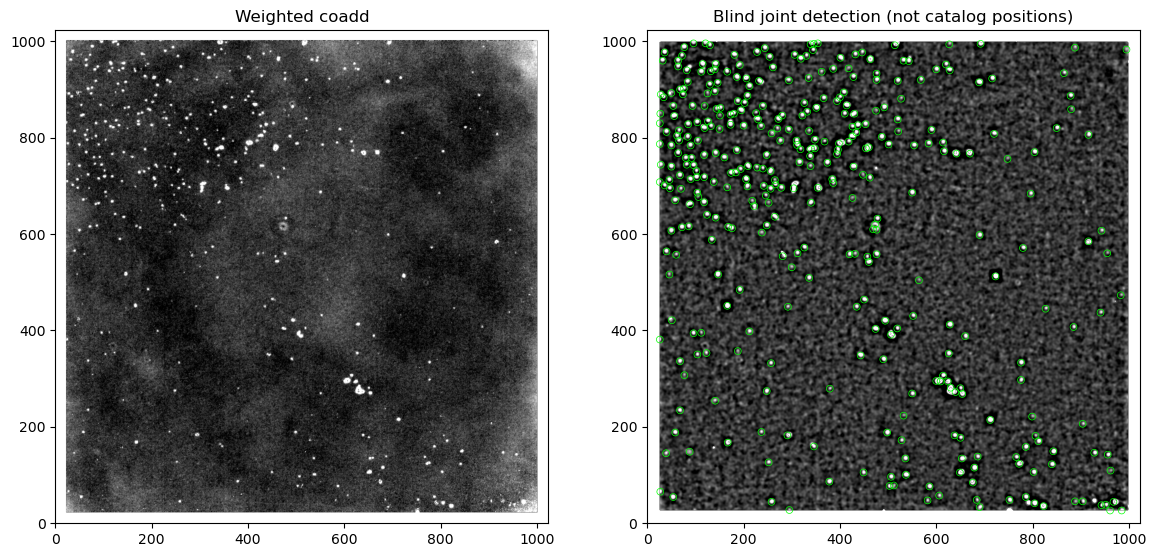

,x,y,snr_empirical,snr_even,snr_odd,flux,coverage,both_halves_ge3
0,723,512,108.687410,105.022922,105.430943,97297.544838,80.0,True
1,166,451,71.724393,69.946453,68.934885,64183.125314,80.0,True
2,804,41,29.565370,28.442613,28.805541,29775.691659,80.0,True
3,823,35,28.940046,27.920038,28.116636,29845.447858,76.0,True
4,712,214,28.934933,27.568618,28.457341,30768.999675,77.0,True
5,692,995,27.774510,27.473621,26.299660,30333.294650,73.0,True
6,689,915,27.538651,27.007089,26.308681,29507.642022,77.0,True
7,649,105,26.603729,25.234000,26.279139,26303.866542,80.0,True
8,679,115,26.583486,25.757519,25.716202,26306.051207,80.0,True
9,463,963,26.555038,26.387576,25.000127,29491.401468,70.0,True


In [5]:
summaries=[json.loads((JOINT/s/'summary.json').read_text()) for s in sequences]
display(pd.DataFrame(summaries)[['sequence','frames','detections_ge5','detections_both_halves_ge3','negative_peaks_ge5','empirical_noise_scale','shared_structure_warning','null_robust_std','psf_fallback_frames','transparency_fallback_frames']])
sources=pd.read_csv(JOINT/SEQUENCE/'blind_sources.csv')
coadd=fits.getdata(JOINT/SEQUENCE/f'weighted_coadd_{SEQUENCE}.fits')
score=fits.getdata(JOINT/SEQUENCE/f'joint_score_{SEQUENCE}.fits')
fig,axes=plt.subplots(1,2,figsize=(14,7))
lo,hi=np.nanpercentile(coadd,[2,99.5])
axes[0].imshow(coadd,origin='lower',cmap='gray',vmin=lo,vmax=hi)
axes[1].imshow(score,origin='lower',cmap='gray',vmin=-2,vmax=8)
axes[1].scatter(sources.x,sources.y,s=24,facecolors='none',edgecolors='lime',linewidths=.5)
axes[0].set_title('Weighted coadd'); axes[1].set_title('Blind joint detection (not catalog positions)')
plt.show()
display(sources.head(20))

## 后续 ASTERIS 比较的边界

本次未训练，旧模型和 coadd 仍对应旧预处理。未来比较模型时必须用同一版上游输入、同一冻结测试帧与曝光数，
重新 prepare 盲配准 manifest；不能把当前 80 帧联合检测与旧 16 帧测试 coadd 直接比较并宣称模型提升。

## 5. 真实星表弱源位置可视化（仅展示，不参与处理）

复用已保存的 2MASS / Gaia 匹配信息及 `weak_sources.csv`，仅覆盖已标定的
`90000002`、`90000003`，每个序列固定 12 个 W01–W12。其余序列没有已核验的星表解，不能套用这些位置。

新共加图使用首曝光坐标，旧 ASTERIS 图使用历史配准坐标。
下面先以**图像自动星点**估计旧参考图到新共加图的平移（至少 6 个匹配星、每轴 RMS≤0.75 像素），
再整体转换已有星表位置；不在弱源附近寻找峰值、不重新筛选弱源，不回写 FITS、星表、检测列表或模型。

输出 `figures/catalog_validation_output/{sequence}/`：
4 张全幅标注图（新 weighted_coadd、joint_score、旧 ASTERIS160/400）、3 页局部放大图、
精确绘图坐标 CSV 和校验/来源 JSON。青色圆圈是星表预测位置，橙色表示该位置像元无效，**不是检出标志**。
坐标为零基，显示采用 origin=lower；圆圈半径只是视觉标记，不是天体测量误差。

**盲元显示：**默认将共加图自身 DQ 的 DO_NOT_USE 和非有限值显示为不透明中性灰；
不直接叠加原始探测器盲元表，仍有效的部分覆盖像元保留。旧 FITS 没有 DQ 时仅屏蔽非有限值，不能把亮点自动判成盲元。
另在 `display_interpolated/` 输出 7 张标明 DISPLAY-ONLY INTERPOLATED 的展示副本：
只用原有效邻域插值不超过 16 像素的封闭缺口，大缺口和边界仍为灰色；不改任何有效像元。
两种版本使用相同的原有效像元拉伸和坐标有效性标记。填补值不是观测，不可用于检出或测光，也不回写 FITS。

**解释边界：**这是固定的历史弱源样本（原先按旧输入的峰值 SNR / K 等条件选取），不是完备星表或无偏检测测试。
当前共加/检测图使用 80 帧，旧论文版共加使用 16 帧且预处理不同；各图/局部使用独立显示拉伸，
不能通过亮暗或平滑程度直接宣称模型性能提高。已有 WCS 误差与新平移残差会分别记录。

本段可独立运行，只读取本地已存在的数据，不联网、不训练、不重新执行上游流程。
重复运行仅更新本段在 figures 中生成的图和说明表。

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display, Image as DisplayImage

start = Path.cwd().resolve()
CATALOG_PROJECT_ROOT = next(p for p in (start, *start.parents) if (p / "src" / "astr_ir").is_dir())
sys.path.insert(0, str(CATALOG_PROJECT_ROOT / "src"))
from astr_ir.evaluation.catalog_visualization import export_catalog_validation

CATALOG_SEQUENCES = ("90000002", "90000003")  # 目前有已核验星表的两个序列
CATALOG_FIGURE_ROOT = CATALOG_PROJECT_ROOT / "figures" / "catalog_validation_output"
catalog_visualizations = export_catalog_validation(
    CATALOG_PROJECT_ROOT, sequences=CATALOG_SEQUENCES,
    output_dir=CATALOG_FIGURE_ROOT, dpi=160, cutout_half_size=24,
    export_interpolated=True, max_hole_pixels=16,  # 仅生成展示副本，不修改科学数据
)
display(pd.DataFrame(catalog_visualizations)[[
    "sequence", "weak_sources", "matched_stars", "transfer_rms_pix", "original_wcs_rms_pix"
]])
print("标注图和逐源坐标已保存至:", CATALOG_FIGURE_ROOT)
for result in catalog_visualizations:
    print(result["sequence"], "完整图:", result["weighted_coadd"])
    print("局部放大图:", *result["cutouts"], sep="\n")
    if result["display_interpolated"] is not None:
        print("仅显示用插值版:", result["display_interpolated"]["overlays"]["weighted_coadd"])

,sequence,weak_sources,matched_stars,transfer_rms_pix,original_wcs_rms_pix
0,90000002,12,24,0.243799,0.897082
1,90000003,12,34,0.157395,0.200961


标注图和逐源坐标已保存至: D:\Astr_IR\code\figures\catalog_validation_output
90000002 完整图: D:\Astr_IR\code\figures\catalog_validation_output\90000002\90000002_weighted_coadd_catalog_overlay.png
局部放大图:
D:\Astr_IR\code\figures\catalog_validation_output\90000002\90000002_weak_source_cutouts_01.png
D:\Astr_IR\code\figures\catalog_validation_output\90000002\90000002_weak_source_cutouts_02.png
D:\Astr_IR\code\figures\catalog_validation_output\90000002\90000002_weak_source_cutouts_03.png
仅显示用插值版: D:\Astr_IR\code\figures\catalog_validation_output\90000002\display_interpolated\90000002_weighted_coadd_catalog_overlay.png
90000003 完整图: D:\Astr_IR\code\figures\catalog_validation_output\90000003\90000003_weighted_coadd_catalog_overlay.png
局部放大图:
D:\Astr_IR\code\figures\catalog_validation_output\90000003\90000003_weak_source_cutouts_01.png
D:\Astr_IR\code\figures\catalog_validation_output\90000003\90000003_weak_source_cutouts_02.png
D:\Astr_IR\code\figures\catalog_validation_output\90000003\90000003_weak_source_

灰色掩膜版：无效像元为灰色，没有填补。


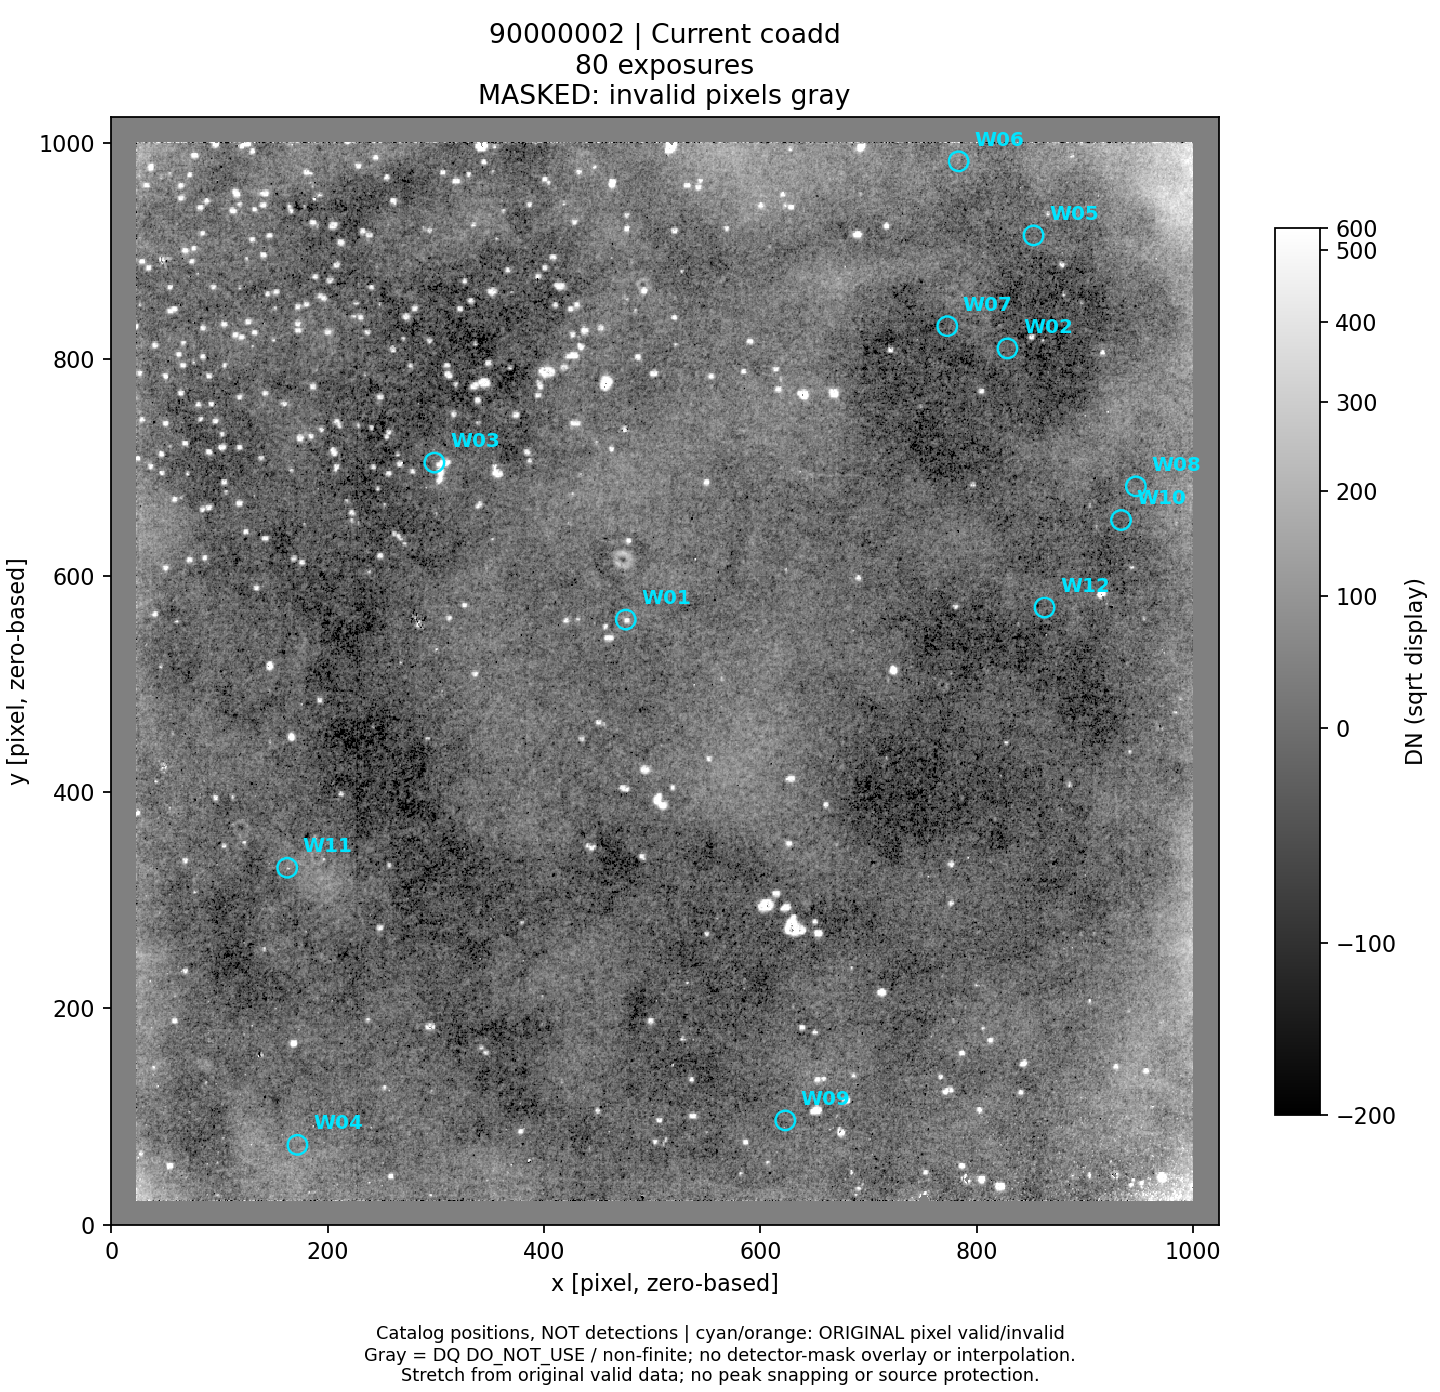

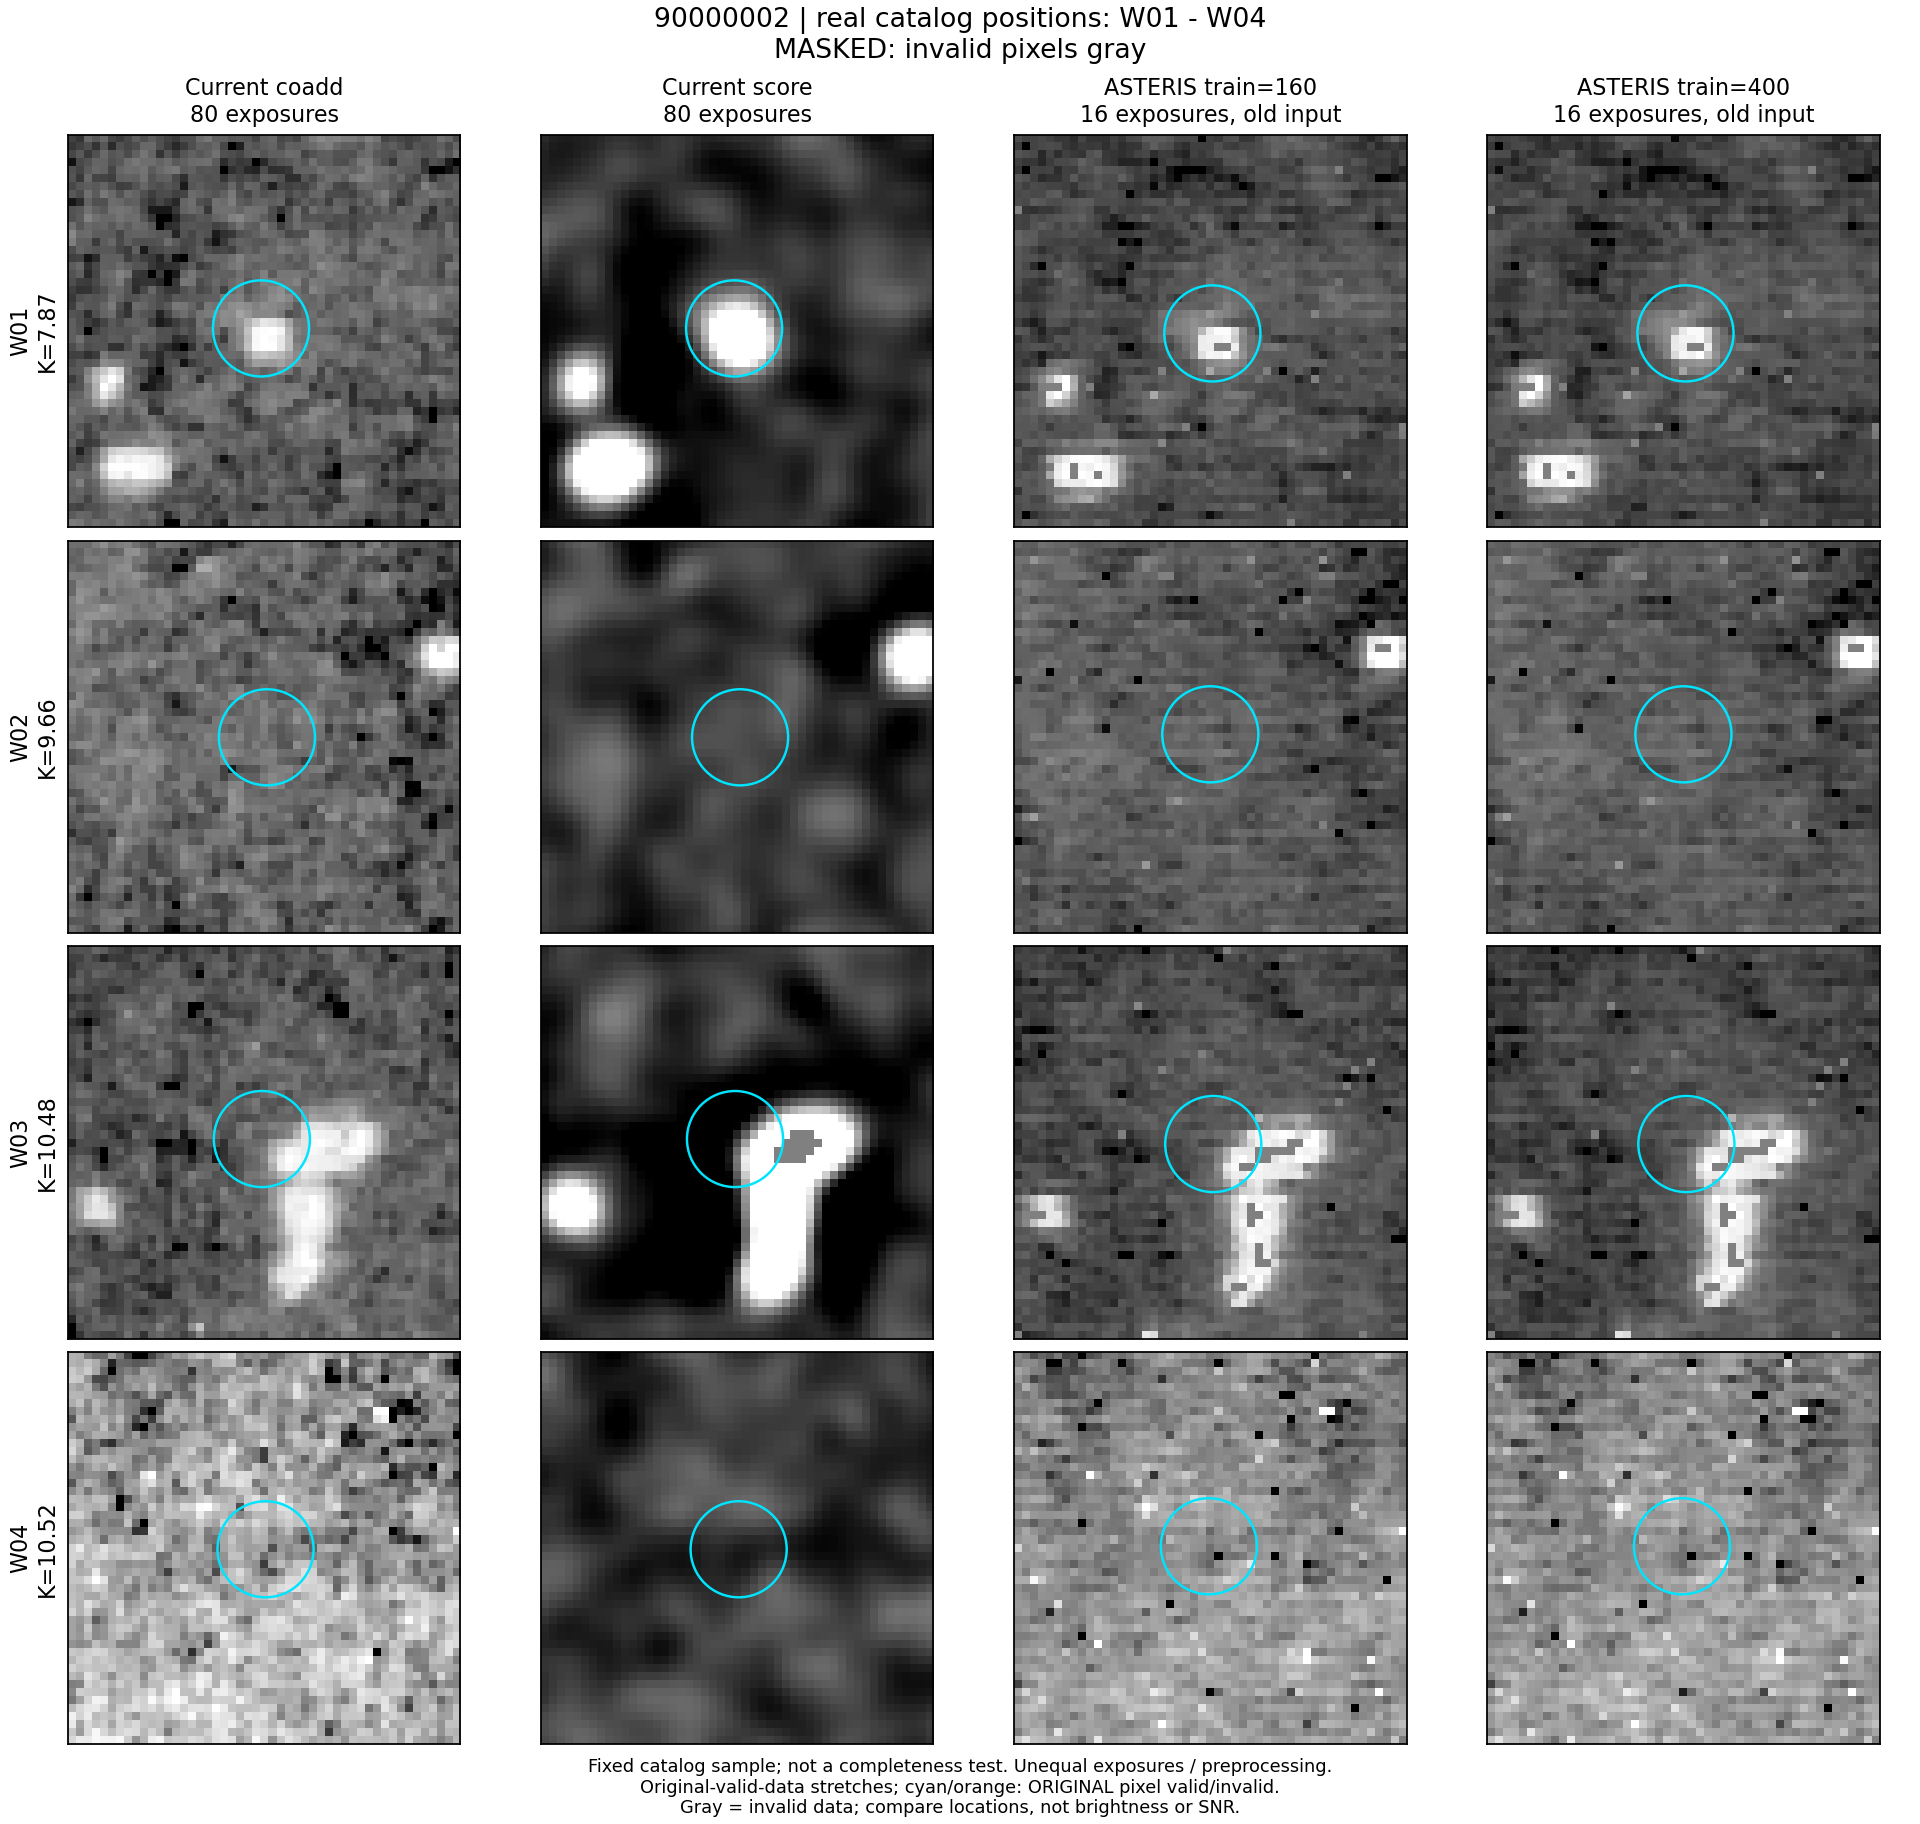

In [2]:
# 可切换到 "90000003"；文件夹中还包含 joint_score 和两个 ASTERIS 结果。
SHOW_SEQUENCE = "90000002"
SHOW_INTERPOLATED = False  # 默认严谨的灰色掩膜版；True 仅切换到展示副本
selected = next(item for item in catalog_visualizations if item["sequence"] == SHOW_SEQUENCE)
if SHOW_INTERPOLATED:
    if selected["display_interpolated"] is None:
        raise ValueError("请先设置 export_interpolated=True 并运行上一单元")
    shown_overlays = selected["display_interpolated"]["overlays"]
    shown_cutouts = selected["display_interpolated"]["cutouts"]
    print("仅显示用插值版：填补像元不是观测，不用于检出或测光。")
else:
    shown_overlays, shown_cutouts = selected, selected["cutouts"]
    print("灰色掩膜版：无效像元为灰色，没有填补。")
display(DisplayImage(filename=shown_overlays["weighted_coadd"], width=1000))
display(DisplayImage(filename=shown_cutouts[0], width=1100))

## 6. 弱源检出改进实验（未训练；全部运行开关默认关闭）

先在冻结的 validation 曝光上做逐阶段随机注入，比较 32/64 网格与 1/3/5 滤波。
模拟源从原始曝光副本注入，经历 raw → flicker → 单轮/两轮 background → 盲检测；
未显式提供 checkpoint 时 ASTERIS 阶段跳过，不加载权重、不训练。
仅读取 manifest 的文件名、序列、帧号和 split，不使用历史目标坐标或 SNR。

两轮背景将粗处理共加图中自动发现的源投影回单帧，第二轮重新拟合原 flicker 输入。
V3 检测比较圆高斯、椭圆高斯、Moffat 和经验 PSF，采用局部噪声、原曝光联合拟合和最多三轮残差检测。
星数不足时明确回退；大源组改用稀疏联合拟合，真正退化或非正通量仍标记。白化保持关闭，输出相关性诊断。

所有实验写入新目录，已有输出时拒绝覆盖。主流程仍为 flicker → background → N2N 或 ASTERIS，V3 是评估支路。
下方 validation 小样本命令只是入口，不会因打开 Notebook 而运行。
`source_recovery.csv` 的配对通量响应用于定位信号损失，不等于检出；真实星场的新增未匹配峰不能直接算作假源。
固定误报预算需先用独立无源模拟的峰值分数调用 `select_threshold_from_null` 冻结阈值，再用独立 test 帧/随机种子验证。
星表仍只在结果冻结后供人眼核验，不作为参数筛选目标。第 1–5 节仍展示历史结果，不代表 V3 已重跑。

In [ ]:
from pathlib import Path
import sys, subprocess
start = Path.cwd().resolve()
WEAK_ROOT = next(p for p in (start, *start.parents) if (p / "src" / "astr_ir").is_dir())
EXPERIMENT_ROOT = WEAK_ROOT / "data" / "processed" / "weak_source_v3_trial01"
FROZEN_SPLIT = WEAK_ROOT / "data" / "processed" / "asteris_paper_400" / "manifests" / "split_manifest.csv"
WEAK_SEQUENCE = "90000002"
RUN_STAGE_RECOVERY = False
RUN_TWO_PASS_BACKGROUND = False
RUN_V3_DETECTION = False
# 每次实验使用新的 EXPERIMENT_ROOT；不能借 --overwrite 覆盖旧科学结果。
# 正式 test 验证要另设目录、独立 seed，且不要依据星表位置挑选参数。
if RUN_STAGE_RECOVERY:
    subprocess.run([sys.executable, str(WEAK_ROOT / "scripts/evaluation/run_stage_recovery.py"),
        "--split-manifest", str(FROZEN_SPLIT), "--sequence", WEAK_SEQUENCE,
        "--phase", "validation", "--limit", "8", "--sources", "4", "--repeats", "1",
        "--fluxes", "6000", "12000", "--ablation",
        "--output-root", str(EXPERIMENT_ROOT / "recovery_validation")], cwd=WEAK_ROOT, check=True)
if RUN_TWO_PASS_BACKGROUND:
    subprocess.run([sys.executable, str(WEAK_ROOT / "scripts/run_background.py"),
        "--two-pass", "--sequences", WEAK_SEQUENCE, "--box-size", "64", "--filter-size", "5",
        "--split-manifest", str(FROZEN_SPLIT),
        "--output-root", str(EXPERIMENT_ROOT / "background")], cwd=WEAK_ROOT, check=True)
if RUN_V3_DETECTION:
    subprocess.run([sys.executable, str(WEAK_ROOT / "scripts/evaluation/run_blind_joint_detection.py"),
        "--method", "v3", "--input-root", str(EXPERIMENT_ROOT / "background"),
        "--output-root", str(EXPERIMENT_ROOT / "joint"), "--sequences", WEAK_SEQUENCE], cwd=WEAK_ROOT, check=True)
print("运行开关:", RUN_STAGE_RECOVERY, RUN_TWO_PASS_BACKGROUND, RUN_V3_DETECTION)
print("独立实验目录:", EXPERIMENT_ROOT)

## 7. 2026-08-26 实测验证结果（只读展示）

本节只读取独立实验目录，不执行预处理、训练或推理。使用冻结 validation 帧与模拟源，星表不参与。
网格消融使用每序列 4 帧，配对注入使用每序列 8 帧、4 个位置和 6000/12000 DN 档位；这是诊断小样本，
不是独立 test 集性能验收。旧 400 帧检查点在新背景上的结果是跨预处理对照，不代表已重训。
`paper_input_coadd` 与 `asteris` 是同一批曝光、同一共加输入和相同单图盲检的网络对照；
不能把它们与原生多曝光检测的全部差别都归因于网络。

详细解释见 `docs/evaluation/validation_20260826.md`。下面只展示已完整结束的实验。

In [ ]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display
start = Path.cwd().resolve()
RESULT_PROJECT = next(p for p in (start, *start.parents) if (p / "src" / "astr_ir").is_dir())
RESULT_ROOT = RESULT_PROJECT / "data/processed/weak_source_v3_validation_20260826"
screen = RESULT_ROOT / "background_screen/summary.csv"
if screen.exists():
    meshes = pd.read_csv(screen, dtype={"sequence": str})
    display(meshes.loc[meshes["mode"].eq("two_pass") &
        ((meshes.box.eq(32) & meshes["filter"].eq(1)) | (meshes.box.eq(64) & meshes["filter"].eq(5)))])
completed = []
for path in sorted(RESULT_ROOT.glob("*/stage_summary.csv")):
    progress = json.loads((path.parent / "progress.json").read_text(encoding="utf-8"))
    if progress.get("complete"):
        table = pd.read_csv(path)
        table.insert(0, "experiment", path.parent.name)
        completed.append(table)
if completed:
    recovery_results = pd.concat(completed, ignore_index=True)
    display(recovery_results.loc[recovery_results.threshold.eq(5), ["experiment", "stage", "flux",
        "eligible_new", "recovered_new", "median_flux_response", "new_unmatched_candidates"]])
    print("阈值 5 是经验分数，不是已校准的 5-sigma 误报概率。新增未匹配峰不等于假源。")
else:
    print("还没有完成的配对注入结果。")
misses = RESULT_ROOT / "miss_diagnostic/diagnostic.json"
if misses.exists():
    display(pd.json_normalize(json.loads(misses.read_text(encoding="utf-8")))[["x", "y", "recovered", "score",
        "nearest_distance", "nearest.fit_flag"]])
decision = RESULT_ROOT / "validation_summary.json"
if decision.exists():
    print(json.loads(decision.read_text(encoding="utf-8")).get("training_decision", "尚未记录训练决定"))
print("结果目录:", RESULT_ROOT)

## 8. 拥挤源组修复复核（只读，不训练）

`max_group=12` 改为稠密/稀疏路径切换点，不再整组拒绝；大组在原始有效像元上联合拟合通量和邻源协方差。
局部窗口只细化位置，整组目标改善后才接受。真正退化、非正通量及覆盖不足仍拒绝，阈值不变。
这里复用上一轮两个序列的固定 validation 曝光/模拟位置，独立保存旧规则与新拟合的对照。
旧规则分支只模拟此前的组大小拒绝；序列 90000002 的高通量结果还与历史候选表逐列核对。
先在未注入图上识别已有候选，已有位置从新增恢复分母中剔除；不能把更多候选直接当作更多真实弱源。
这不是完整下游流程/网络测试，未使用真实星表调参，未改 FITS 或权重。说明见 `docs/evaluation/crowded_fit_20260826.md`。

In [ ]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display
start = Path.cwd().resolve()
CROWDED_PROJECT = next(p for p in (start, *start.parents) if (p / "src" / "astr_ir").is_dir())
CROWDED_ROOT = CROWDED_PROJECT / "data/processed/crowded_fit_validation_20260826"
for sequence in ("90000002", "90000003"):
    destination = CROWDED_ROOT / sequence
    progress_file = destination / "progress.json"
    if not progress_file.exists() or not json.loads(progress_file.read_text(encoding="utf-8")).get("complete"):
        print(sequence, "尚未完成；不展示部分结果为最终结果")
        continue
    print(sequence, "flux=0 为未注入基线；其余行的 flux 是每曝光积分通量 DN")
    comparison = pd.read_csv(destination / "comparison.csv")
    display(comparison[["method", "flux", "recovered_new", "eligible_new", "preexisting",
        "accepted", "size_rejected", "degenerate", "largest_group", "new_unmatched_candidates"]])
    replay = json.loads((destination / "report.json").read_text(encoding="utf-8"))
    print("历史候选表重现:", replay["historical_candidates_reproduced"])
    display(pd.read_csv(destination / "source_recovery.csv")[["method", "flux", "x", "y",
        "recovered", "preexisting", "nearest_flag", "nearest_group_size"]])
print("新增未匹配候选不等于假源；该小样本不提供固定误报率下的完整度结论。")

## 9. 背景方案与 ASTERIS 同配置对照（只读展示）
先在 validation 选择背景，再在 400 帧固定划分上分别训练对照与新版，最后使用 test 帧验收。
本节不执行处理或训练。真实星表只在最终图像中标注，不能解释为已检出。
详细方案和结果见 docs/evaluation/background_ablation_20260826.md。

In [ ]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image
start = Path.cwd().resolve()
ABLATION_PROJECT = next(p for p in (start, *start.parents) if (p / 'src/astr_ir').is_dir())
ABLATION_ROOT = ABLATION_PROJECT / 'data/processed/background_ablation_20260826'
for name in ('background_selection.csv', 'final_comparison.csv', 'paired_test_comparison.csv'):
    path = ABLATION_ROOT / name
    if path.exists():
        print(name)
        display(pd.read_csv(path))
for path in sorted((ABLATION_ROOT / 'models').glob('*/checkpoints/training_history.csv')):
    print(path.parent.parent.name, '训练记录（完成状态见 training_progress.json）')
    display(pd.read_csv(path).tail())
status = ABLATION_ROOT / 'completion.json'
print(json.loads(status.read_text(encoding='utf-8')) if status.exists() else '实验仍在执行；部分记录不是最终验收。')
preview = ABLATION_PROJECT / 'figures/background_ablation_output/comparison.png'
if preview.exists():
    display(Image(filename=str(preview)))
print('星表可视化目录:', ABLATION_PROJECT / 'figures/background_ablation_output')
print('无源模拟误报预算仅在模拟模型下成立；真实天空未匹配候选不等于假源。')